In [7]:
from typing import TypedDict

from langgraph.graph import StateGraph, END

from langchain_groq import ChatGroq

from pydantic import BaseModel, Field

import os
import json
import subprocess

In [8]:
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [12]:
from typing import List


class Task(BaseModel):
    
    agent: str = Field(
        description="Agent responsible"
    )
    
    task: str = Field(
        description="Task description"
    )


class Plan(BaseModel):
    
    tasks: List[Task]

In [13]:
planner_llm = llm.with_structured_output(
    Plan
)

In [60]:
def planner_node(state):
    
    prompt = f"""
You are a software project planner.

Available agents:
- file
- code
- dependency
- run

IMPORTANT:
Always return tasks in this exact order:

1. file
2. code
3. dependency
4. run

The code task should generate the COMPLETE application.

IMPORTANT:
Generated applications must run automatically.
Do not require user input.

User Request:
{state['user_request']}
"""
    
    result = planner_llm.invoke(prompt)
    
    state["tasks"] = [
        task.model_dump()
        for task in result.tasks
    ]
    
    state["current_task_index"] = 0
    
    print("PLAN:")
    
    for t in state["tasks"]:
        print(t)
    
    return state

In [15]:
def router(state):

    if state.get("has_error"):

        state["has_error"] = False

        return "debug"

    if state.get("retry_run"):

        state["retry_run"] = False

        return "run"

    idx = state["current_task_index"]

    if idx >= len(state["tasks"]):
        return "finish"

    return state["tasks"][idx]["agent"]

In [16]:
import os

WORKSPACE = "workspace"

os.makedirs(WORKSPACE, exist_ok=True)

In [61]:
def file_agent(state):

    #  = state["tasks"][
    #     state["current_task_index"]
    # ]task

    filename = "main.py"

    filepath = os.path.join(
        WORKSPACE,
        filename
    )

    with open(filepath, "w") as f:
        pass

    state["files_created"].append(
        filepath
    )
    state["current_file"] = filepath

    print(f"Created: {filepath}")

    # state["current_task_index"] += 1

    return state

In [18]:
class AgentState(TypedDict):

    user_request: str

    tasks: list

    current_task_index: int

    current_file: str

    files_created: list

    generated_code: dict

    execution_logs: list

    errors: list

    final_output: str

    has_error:False

In [56]:
class CodeOutput(BaseModel):
    code: str

In [57]:
## LLM fro code generation
code_llm = llm.with_structured_output(
    CodeOutput
)

In [74]:
def code_agent(state):

    task = state["tasks"][1]

    filepath = state["current_file"]

    prompt = f"""
You are a Python coding agent.

User Request:
{state["user_request"]}

Generate the COMPLETE Python application.

Rules:
- Generate a complete executable program.
- No explanations.
- No markdown.
- No code fences.
- Ensure all functions are complete.

IMPORTANT:
The program must terminate within 5 seconds.

Never use:
- input()
- while True
- infinite loops
- waiting for user interaction
"""

    result = code_llm.invoke(prompt)



    code = result.code

    with open(filepath, "w") as f:
        f.write(code)

    state["generated_code"][filepath] = code

    print(f"Code written to {filepath}")

    # state["current_task_index"] += 1

    return state

In [63]:
import re
import subprocess
import sys
import importlib


def dependency_agent(state):

    state.setdefault("installed_dependencies", [])
    state.setdefault("errors", [])

    state["has_error"] = False

    filepath = state["current_file"]

    with open(filepath, "r", encoding="utf-8") as f:
        code = f.read()

    imports = set()

    imports.update(
        re.findall(
            r"^\s*import\s+([a-zA-Z_][a-zA-Z0-9_]*)",
            code,
            re.MULTILINE
        )
    )

    imports.update(
        re.findall(
            r"^\s*from\s+([a-zA-Z_][a-zA-Z0-9_]*)\s+import",
            code,
            re.MULTILINE
        )
    )

    BUILTIN_MODULES = {
        "os", "sys", "json", "math", "time",
        "random", "re", "subprocess",
        "pathlib", "typing", "collections",
        "datetime", "itertools",
        "functools", "logging",
        "threading", "asyncio"
    }

    packages = [
        pkg for pkg in imports
        if pkg not in BUILTIN_MODULES
    ]

    print("Dependencies Found:")
    print(packages)

    for package in packages:

        try:

            try:
                importlib.import_module(package)

                print(
                    f"{package} already installed"
                )

            except ImportError:

                print(
                    f"Installing {package}..."
                )

                subprocess.run(
                    [
                        sys.executable,
                        "-m",
                        "pip",
                        "install",
                        package
                    ],
                    check=True,
                    capture_output=True,
                    text=True
                )

                print(
                    f"Installed: {package}"
                )

            if package not in state["installed_dependencies"]:

                state["installed_dependencies"].append(
                    package
                )

        except Exception as e:

            print(
                f"Failed to install {package}"
            )

            state["errors"].append(
                f"Dependency Install Error: {package}\n{str(e)}"
            )

            state["has_error"] = True

    print("Dependency check complete")

    return state

In [64]:
## Run agent

import subprocess
import sys



def run_agent(state):

    filepath = state["current_file"]

    print(f"Running {filepath}")

    result = subprocess.run(
        [sys.executable, filepath],
        capture_output=True,
        text=True,
        timeout=10
    )

    if result.returncode == 0:

        print("Execution Success")

        print(result.stdout)

        state["execution_logs"].append(
            result.stdout
        )

    else:

        print("Execution Failed")

        print(result.stderr)

        state["errors"].append(
            result.stderr
        )

    state["has_error"] = (
    result.returncode != 0)
    # state["current_task_index"] += 1
    return state





In [65]:
class FixedCode(BaseModel):
    code: str

debug_llm = llm.with_structured_output(
    FixedCode
)


In [66]:
def debug_agent(state):

    if state["retry_count"] >= state["max_retries"]:

        print("Maximum retry limit reached")

        return state

    filepath = state["current_file"]

    error = state["errors"][-1]

    with open(filepath, "r", encoding="utf-8") as f:
        current_code = f.read()

    prompt = f"""
You are an expert Python debugging agent.

The following code failed.

CODE:
{current_code}

ERROR:
{error}

Fix the code.

Rules:
- Return complete corrected code.
- Do not explain.
- Do not use input().
- Do not use infinite loops.
- Code must terminate automatically.
- Return only executable Python code.
"""

    result = debug_llm.invoke(prompt)

    fixed_code = result.code

    with open(filepath, "w", encoding="utf-8") as f:
        f.write(fixed_code)

    state["generated_code"][filepath] = fixed_code

    state["retry_count"] += 1

    print("Code fixed by Debug Agent")

    return state

In [26]:
state = {
    "user_request": "Create a python app that uses pandas and prints a dataframe",
    "tasks": [],
    "current_task_index": 0,
    "current_file": "",
    "files_created": [],
    "generated_code": {},
    "execution_logs": [],
    "errors": [],
    "has_error": False,
    "retry_run": False,
    "retry_count": 0,
    "max_retries": 3,
    "final_output": "",
    "installed_dependencies": []
}

In [ ]:
# file_agent(state)
# code_agent(state)
#dependency_agent(state)
# run_agent(state)

Running workspace\main.py
Execution Success
    Name  Age    Country
0   John   28        USA
1   Anna   24         UK
2  Peter   35  Australia
3  Linda   32    Germany



{'user_request': 'Create a python app that uses pandas and prints a dataframe',
 'tasks': [{'agent': 'file',
   'task': 'Create a new python file called main.py'},
  {'agent': 'code',
   'task': 'Write a python application in main.py that uses pandas to create and print a dataframe'},
  {'agent': 'dependency', 'task': 'Install the pandas library'},
  {'agent': 'run', 'task': 'Run the main.py file'}],
 'current_task_index': 5,
 'current_file': 'workspace\\main.py',
 'files_created': ['workspace\\main.py'],
 'generated_code': {'workspace\\main.py': "import pandas as pd\n\ndata = {'Name': ['John', 'Anna', 'Peter', 'Linda'],\n        'Age': [28, 24, 35, 32],\n        'Country': ['USA', 'UK', 'Australia', 'Germany']}\n\ndf = pd.DataFrame(data)\n\nprint(df)"},
 'execution_logs': ['    Name  Age    Country\n0   John   28        USA\n1   Anna   24         UK\n2  Peter   35  Australia\n3  Linda   32    Germany\n'],
 'errors': ['Dependency Install Error: pandas\nc:\\Users\\ASUS\\Desktop\\Coding 

In [27]:
state = planner_node(state)
print(state["tasks"])


PLAN:
{'agent': 'file', 'task': 'Create a new python file called main.py'}
{'agent': 'code', 'task': 'Write a python script in main.py that imports pandas, creates a dataframe and prints it'}
{'agent': 'dependency', 'task': 'Install the pandas library'}
{'agent': 'run', 'task': 'Run the main.py file'}
[{'agent': 'file', 'task': 'Create a new python file called main.py'}, {'agent': 'code', 'task': 'Write a python script in main.py that imports pandas, creates a dataframe and prints it'}, {'agent': 'dependency', 'task': 'Install the pandas library'}, {'agent': 'run', 'task': 'Run the main.py file'}]


In [28]:
def execute_workflow(state):

    while True:

        next_agent = router(state)

        print(f"\nNext Agent: {next_agent}")

        if next_agent == "finish":
            print("\nWorkflow Completed")
            break

        elif next_agent == "file":
            state = file_agent(state)

        elif next_agent == "code":
            state = code_agent(state)

            # INTENTIONALLY BREAK CODE
            with open(state["current_file"], "w") as f:
                f.write("""
print("Starting...")
print(undefined_variable)
""")

            print("Injected broken code")

        elif next_agent == "dependency":
            state = dependency_agent(state)

        elif next_agent == "run":
            state = run_agent(state)

        elif next_agent == "debug":
            state = debug_agent(state)

    return state

In [29]:
state=execute_workflow(state)



Next Agent: file
Created: workspace\main.py

Next Agent: code
Code written to workspace\main.py
Injected broken code

Next Agent: dependency
Dependencies Found:
[]
Dependency check complete

Next Agent: run
Running workspace\main.py
Execution Failed
Traceback (most recent call last):
  File "c:\Users\ASUS\Desktop\Coding agent\workspace\main.py", line 3, in <module>
    print(undefined_variable)
          ^^^^^^^^^^^^^^^^^^
NameError: name 'undefined_variable' is not defined


Next Agent: debug
Code fixed by Debug Agent

Next Agent: finish

Workflow Completed


Move into Langgraph

In [67]:
from typing import TypedDict


class AgentState(TypedDict):

    user_request: str

    tasks: list

    current_file: str

    files_created: list

    generated_code: dict

    installed_dependencies: list

    execution_logs: list

    errors: list

    has_error: bool

    retry_count: int

    max_retries: int

    final_output: str

In [75]:
from langgraph.graph import StateGraph
from langgraph.graph import END

graph = StateGraph(
    AgentState
)


graph.add_node(
    "planner",
    planner_node
)

graph.add_node(
    "file",
    file_agent
)

graph.add_node(
    "code",
    code_agent
)

graph.add_node(
    "dependency",
    dependency_agent
)

graph.add_node(
    "run",
    run_agent
)

graph.add_node(
    "debug",
    debug_agent
)

In [76]:
graph.set_entry_point(
    "planner"
)

graph.add_edge(
    "planner",
    "file"
)

graph.add_edge(
    "file",
    "code"
)

graph.add_edge(
    "code",
    "dependency"
)

graph.add_edge(
    "dependency",
    "run"
)


def route_after_run(state):

    if state["has_error"]:
        return "debug"

    return "finish"

graph.add_conditional_edges(
    "run",
    route_after_run,
    {
        "debug": "debug",
        "finish": END
    }
)

def route_after_debug(state):

    if state["retry_count"] >= state["max_retries"]:
        return "finish"

    return "run"

graph.add_conditional_edges(
    "debug",
    route_after_debug,
    {
        "run": "run",
        "finish": END
    }
)


app = graph.compile()

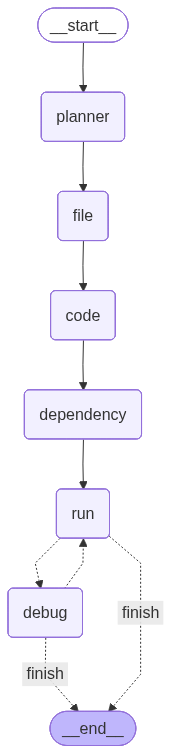

In [77]:
app

In [87]:
state = {

    "user_request":
        "Create a python program for full calculator but dont take user input",

    "tasks": [],

    "current_file": "",

    "files_created": [],

    "generated_code": {},

    "installed_dependencies": [],

    "execution_logs": [],

    "errors": [],

    "has_error": False,

    "retry_count": 0,

    "max_retries": 3,

    "final_output": ""
}

In [88]:
state

{'user_request': 'Create a python program for full calculator but dont take user input',
 'tasks': [],
 'current_file': '',
 'files_created': [],
 'generated_code': {},
 'installed_dependencies': [],
 'execution_logs': [],
 'errors': [],
 'has_error': False,
 'retry_count': 0,
 'max_retries': 3,
 'final_output': ''}

In [89]:
result = app.invoke(state)

PLAN:
{'agent': 'file', 'task': 'Create a new python file for the calculator program'}
{'agent': 'code', 'task': 'Generate the complete python application for a full calculator with automated tests and example usage'}
{'agent': 'dependency', 'task': 'Install necessary python dependencies for the calculator program'}
{'agent': 'run', 'task': 'Run the calculator program automatically'}
Created: workspace\main.py
Code written to workspace\main.py
Dependencies Found:
[]
Dependency check complete
Running workspace\main.py
Execution Success
Addition:  15
Subtraction:  5
Multiplication:  50
Division:  2.0
Power:  100
Square root:  4.0

